# Predicting Adult Income with Gradient Boosting Classifier

**Student Name:** Wickramasinghe M.P.T.H

**IT Number:** IT25300115  
**Group ID:** 2026-Y2-S1-MLB-B1G1-07  
**Model:** Gradient Boosting Classifier

---

This notebook evaluates Gradient Boosting Classifier configurations for the Adult Income classification task. It compares different learning rates, tree depths, number of estimators, subsampling strategies, and a systematic `RandomizedSearchCV` configuration.

### How to use this notebook
1. Run the code cells in order, starting with Section 2.
2. Ensure `results/outputs/adult_processed.csv` is available; the setup cell checks several project-relative locations.
3. Review the comparison table, selected-model evaluation, feature importance, fairness check, and example prediction.

Charts are saved under `results/eda_visualizations/models`. Results can vary slightly depending on the prepared dataset and machine.

## 1. The task and the Gradient Boosting idea

### What is being predicted?
The prepared Adult Income dataset contains census-related attributes. The target column is `income`, with two classes: `<=50K` and `>50K`. The Gradient Boosting model uses the other columns to predict the target class.

### How does Gradient Boosting make a prediction?
Gradient Boosting is a sequential ensemble method that builds one decision tree at a time. Each new tree attempts to correct the errors (residuals) made by the previous trees. The final prediction is the weighted sum of all tree predictions. Unlike Random Forest, which trains trees in parallel using bootstrapped samples, Gradient Boosting trains trees one after another, each one focusing on the mistakes of its predecessors.

The key parameter is the **learning rate**, which controls how much each tree contributes to the overall model. A smaller learning rate requires more trees but often produces better generalization.

### Why is Gradient Boosting suitable here?
- The target is binary, which fits a classification task.
- Gradient Boosting can model non-linear relationships and feature interactions between income and attributes such as education, age, occupation, and hours worked.
- It tends to achieve higher accuracy than individual decision trees by correcting errors iteratively.
- It provides feature importance values that can be inspected to understand which input columns contribute most to the model.
- It handles class imbalance through sample weighting and the loss function.
- Unlike some models, Gradient Boosting does not require feature scaling, as it is tree-based.

## 2. Load the data and prepare a fair comparison

The setup cell loads the prepared CSV, separates `income` from the input features, and creates an 80/20 stratified train/test split. The same split is used across all Gradient Boosting variants so the comparison is consistent.

Cross-validation is performed only on the training data. The test set is used for reporting the performance of each variant.

In [2]:
import os
from pathlib import Path
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42

candidates = [
    '../../results/outputs/adult_processed.csv',
    '../results/outputs/adult_processed.csv',
    'results/outputs/adult_processed.csv',
    'adult_processed.csv'
]
DATA_PATH = next((c for c in candidates if os.path.exists(c)), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "adult_processed.csv was not found. Place it in results/outputs/ "
        "or update DATA_PATH in this cell."
    )

df = pd.read_csv(DATA_PATH)

print(f"Loaded dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
display(df.head())

if 'income' not in df.columns:
    raise ValueError("The dataset must contain an 'income' target column.")

X = df.drop(columns=['income'])
y = df['income'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Train size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}")
print(f"Positive class (>50K) prevalence: {y.mean():.2%}")
print("\nClass counts:")
print(y.value_counts().rename({0: '<=50K', 1: '>50K'}))

Loaded dataset: 32,058 rows, 83 columns


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,1.360450,1.712817,-0.41443,-0.232725,5.989283,-0.008462,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,-1.356863,-0.310543,-0.02313,-0.232725,5.989283,-2.567806,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,-0.402131,0.935970,-0.41443,-0.232725,5.989283,3.745241,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
3,-0.622454,0.637500,-0.02313,-0.232725,5.989283,-0.008462,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,0.111955,0.928000,1.15077,-0.232725,5.989283,0.674029,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


Train size: 25,646 | Test size: 6,412
Positive class (>50K) prevalence: 23.48%

Class counts:
income
<=50K    24532
>50K      7526
Name: count, dtype: int64


## 3. How model performance is measured

The target classes are imbalanced, so accuracy is not used alone.

- **Accuracy:** Overall proportion of correct predictions.
- **Precision:** Of the people predicted as `>50K`, how many are actually `>50K`?
- **Recall:** Of the people actually in the `>50K` class, how many are identified?
- **F1-score:** Harmonic mean of precision and recall; this is the main comparison metric.
- **ROC-AUC:** Measures ranking quality across classification thresholds.
- **Inference time:** Approximate time required to predict the test set on the current machine.

Five-fold stratified cross-validation is run on the training data. Test metrics are also reported for every variant. The same test set is used for the experiment comparison, so the comparison should not be treated as a completely untouched final estimate.

In [3]:
gb_results = []

def evaluate_gb_variant(name, model, X_tr, y_tr, X_te, y_te,
                        preprocessing_desc, hyperparams_desc):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    start = time.time()
    cv_scores = cross_validate(
        model,
        X_tr,
        y_tr,
        cv=cv,
        scoring=['f1', 'precision', 'recall', 'roc_auc'],
        n_jobs=-1
    )
    cv_elapsed = time.time() - start

    model.fit(X_tr, y_tr)

    pred_start = time.time()
    y_pred = model.predict(X_te)
    pred_time = time.time() - pred_start

    y_prob = model.predict_proba(X_te)[:, 1]

    row = {
        'Variant': name,
        'Preprocessing': preprocessing_desc,
        'Hyperparameters': hyperparams_desc,
        'CV 5-Fold F1': round(cv_scores['test_f1'].mean(), 4),
        'CV 5-Fold AUC': round(cv_scores['test_roc_auc'].mean(), 4),
        'Test Accuracy': round(accuracy_score(y_te, y_pred), 4),
        'Test Precision': round(precision_score(y_te, y_pred, zero_division=0), 4),
        'Test Recall': round(recall_score(y_te, y_pred, zero_division=0), 4),
        'Test F1-Score': round(f1_score(y_te, y_pred, zero_division=0), 4),
        'Test ROC-AUC': round(roc_auc_score(y_te, y_prob), 4),
        'Inference Time (s)': round(pred_time, 4),
        'CV Time (s)': round(cv_elapsed, 2)
    }

    gb_results.append(row)

    print(
        f"[{name}] CV F1={row['CV 5-Fold F1']:.4f} | "
        f"Test F1={row['Test F1-Score']:.4f} | "
        f"Test Recall={row['Test Recall']:.4f} | "
        f"Test AUC={row['Test ROC-AUC']:.4f} | "
        f"Inference={row['Inference Time (s)']:.4f}s"
    )

    return model, y_pred, y_prob, row

## 4. Compare 10 Gradient Boosting configurations

The following variants intentionally change one or more Gradient Boosting settings so the effect can be compared on the same dataset.

| Variant | Main change |
| --- | --- |
| V1 | Baseline Gradient Boosting with 100 trees and learning_rate=0.1 |
| V2 | More trees (200 estimators) |
| V3 | Smaller learning rate (0.05) with more trees (300) |
| V4 | Deeper trees (`max_depth=5`) |
| V5 | Shallow trees (`max_depth=2`) with many estimators (500) |
| V6 | Stochastic Gradient Boosting (`subsample=0.8`) |
| V7 | Aggressive subsampling (`subsample=0.6`) with feature subsampling (`max_features='sqrt'`) |
| V8 | Higher learning rate (0.2) for faster convergence |
| V9 | Regularisation with `min_samples_leaf=10` and `min_samples_split=20` |
| V10 | `RandomizedSearchCV` tuned Gradient Boosting using five-fold CV F1-score |

Gradient Boosting does not require standardisation or normalisation because its tree split rules are based on feature thresholds rather than distance calculations.

In [4]:
# Variant 1: Baseline Gradient Boosting
v1_gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=RANDOM_STATE
)

gb1, p1, pr1, r1 = evaluate_gb_variant(
    "V1: Baseline (100 trees, lr=0.1)",
    v1_gb, X_train, y_train, X_test, y_test,
    "Raw prepared features (no scaling required)",
    "n_estimators=100, learning_rate=0.1, max_depth=3"
)

[V1: Baseline (100 trees, lr=0.1)] CV F1=0.6740 | Test F1=0.6620 | Test Recall=0.5701 | Test AUC=0.9199 | Inference=0.0151s


In [5]:
# Variant 2: More trees
v2_gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=RANDOM_STATE
)

gb2, p2, pr2, r2 = evaluate_gb_variant(
    "V2: More Trees (200)",
    v2_gb, X_train, y_train, X_test, y_test,
    "Raw prepared features",
    "n_estimators=200, learning_rate=0.1, max_depth=3"
)

[V2: More Trees (200)] CV F1=0.6913 | Test F1=0.6729 | Test Recall=0.5953 | Test AUC=0.9225 | Inference=0.0214s


In [6]:
# Variant 3: Smaller learning rate with more trees
v3_gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=RANDOM_STATE
)

gb3, p3, pr3, r3 = evaluate_gb_variant(
    "V3: Low LR (0.05, 300 trees)",
    v3_gb, X_train, y_train, X_test, y_test,
    "Raw prepared features",
    "n_estimators=300, learning_rate=0.05, max_depth=3"
)

[V3: Low LR (0.05, 300 trees)] CV F1=0.6837 | Test F1=0.6710 | Test Recall=0.5874 | Test AUC=0.9223 | Inference=0.0429s


In [7]:
# Variant 4: Deeper trees
v4_gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=RANDOM_STATE
)

gb4, p4, pr4, r4 = evaluate_gb_variant(
    "V4: Deeper Trees (depth=5)",
    v4_gb, X_train, y_train, X_test, y_test,
    "Raw prepared features",
    "n_estimators=100, learning_rate=0.1, max_depth=5"
)

[V4: Deeper Trees (depth=5)] CV F1=0.6991 | Test F1=0.6793 | Test Recall=0.6073 | Test AUC=0.9227 | Inference=0.0208s


In [8]:
# Variant 5: Very shallow trees with many estimators
v5_gb = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=2,
    random_state=RANDOM_STATE
)

gb5, p5, pr5, r5 = evaluate_gb_variant(
    "V5: Shallow (depth=2, 500 trees)",
    v5_gb, X_train, y_train, X_test, y_test,
    "Raw prepared features",
    "n_estimators=500, learning_rate=0.05, max_depth=2"
)

[V5: Shallow (depth=2, 500 trees)] CV F1=0.6776 | Test F1=0.6613 | Test Recall=0.5741 | Test AUC=0.9178 | Inference=0.0329s


In [9]:
# Variant 6: Stochastic Gradient Boosting (subsample=0.8)
v6_gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    random_state=RANDOM_STATE
)

gb6, p6, pr6, r6 = evaluate_gb_variant(
    "V6: Stochastic (subsample=0.8)",
    v6_gb, X_train, y_train, X_test, y_test,
    "Raw prepared features",
    "n_estimators=200, learning_rate=0.1, max_depth=3, subsample=0.8"
)

[V6: Stochastic (subsample=0.8)] CV F1=0.6906 | Test F1=0.6729 | Test Recall=0.5940 | Test AUC=0.9218 | Inference=0.0236s


In [10]:
# Variant 7: Aggressive subsampling + feature subsampling
v7_gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.6,
    max_features='sqrt',
    random_state=RANDOM_STATE
)

gb7, p7, pr7, r7 = evaluate_gb_variant(
    "V7: Aggressive subsample (0.6) + sqrt",
    v7_gb, X_train, y_train, X_test, y_test,
    "Raw prepared features",
    "n_estimators=200, learning_rate=0.1, max_depth=4, subsample=0.6, max_features='sqrt'"
)

[V7: Aggressive subsample (0.6) + sqrt] CV F1=0.6856 | Test F1=0.6767 | Test Recall=0.5993 | Test AUC=0.9186 | Inference=0.0285s


In [11]:
# Variant 8: Higher learning rate
v8_gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.2,
    max_depth=3,
    random_state=RANDOM_STATE
)

gb8, p8, pr8, r8 = evaluate_gb_variant(
    "V8: Higher LR (0.2)",
    v8_gb, X_train, y_train, X_test, y_test,
    "Raw prepared features",
    "n_estimators=100, learning_rate=0.2, max_depth=3"
)

[V8: Higher LR (0.2)] CV F1=0.6922 | Test F1=0.6737 | Test Recall=0.5960 | Test AUC=0.9224 | Inference=0.0158s


In [12]:
# Variant 9: Regularisation with min_samples_leaf and min_samples_split
v9_gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    min_samples_leaf=10,
    min_samples_split=20,
    random_state=RANDOM_STATE
)

gb9, p9, pr9, r9 = evaluate_gb_variant(
    "V9: Regularised (leaf=10, split=20)",
    v9_gb, X_train, y_train, X_test, y_test,
    "Raw prepared features",
    "n_estimators=200, learning_rate=0.1, max_depth=4, min_samples_leaf=10, min_samples_split=20"
)

[V9: Regularised (leaf=10, split=20)] CV F1=0.6995 | Test F1=0.6869 | Test Recall=0.6166 | Test AUC=0.9255 | Inference=0.0248s


In [13]:
# Variant 10: Systematic RandomizedSearchCV tuning
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'subsample': [0.6, 0.8, 1.0],
    'max_features': ['sqrt', 'log2', None]
}

print("Tuning Gradient Boosting with 5-Fold Stratified RandomizedSearchCV...")

gb_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_distributions=param_dist,
    n_iter=30,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)

gb_search.fit(X_train, y_train)

print("Best Parameters:")
print(gb_search.best_params_)
print(f"Best 5-Fold CV F1 Score: {gb_search.best_score_:.4f}")

gb10, p10, pr10, r10 = evaluate_gb_variant(
    "V10: RandomizedSearchCV Optimal",
    gb_search.best_estimator_,
    X_train, y_train, X_test, y_test,
    "Raw prepared features",
    str(gb_search.best_params_)
)

best_gb = gb10

Tuning Gradient Boosting with 5-Fold Stratified RandomizedSearchCV...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters:
{'subsample': 0.8, 'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 5, 'learning_rate': 0.05}
Best 5-Fold CV F1 Score: 0.7056
[V10: RandomizedSearchCV Optimal] CV F1=0.7056 | Test F1=0.6904 | Test Recall=0.6306 | Test AUC=0.9238 | Inference=0.0516s


## 5. Read the comparison table and chart

The table is sorted by test F1-score. The chart compares test F1-score and ROC-AUC across the ten configurations.

The model with the best test F1-score is the best-performing variant **on this particular test split**. Separately, V10 is the model selected by `RandomizedSearchCV` using training-set cross-validation. These two choices can differ.


=================== GRADIENT BOOSTING PERFORMANCE COMPARISON ===================


,Variant,Preprocessing,Hyperparameters,CV 5-Fold F1,CV 5-Fold AUC,Test Accuracy,Test Precision,Test Recall,Test F1-Score,Test ROC-AUC,Inference Time (s),CV Time (s)
0,V10: RandomizedSearchCV Optimal,Raw prepared features,"{'subsample': 0.8, 'n_estimators': 500, 'min_s...",0.7056,0.9251,0.8673,0.7629,0.6306,0.6904,0.9238,0.0516,21.63
1,"V9: Regularised (leaf=10, split=20)",Raw prepared features,"n_estimators=200, learning_rate=0.1, max_depth...",0.6995,0.9262,0.8681,0.7753,0.6166,0.6869,0.9255,0.0248,13.04
2,V4: Deeper Trees (depth=5),Raw prepared features,"n_estimators=100, learning_rate=0.1, max_depth=5",0.6991,0.9251,0.8654,0.7707,0.6073,0.6793,0.9227,0.0208,13.02
3,V7: Aggressive subsample (0.6) + sqrt,Raw prepared features,"n_estimators=200, learning_rate=0.1, max_depth...",0.6856,0.9200,0.8656,0.7769,0.5993,0.6767,0.9186,0.0285,2.45
4,V8: Higher LR (0.2),Raw prepared features,"n_estimators=100, learning_rate=0.2, max_depth=3",0.6922,0.9238,0.8645,0.7746,0.5960,0.6737,0.9224,0.0158,5.11
5,V2: More Trees (200),Raw prepared features,"n_estimators=200, learning_rate=0.1, max_depth=3",0.6913,0.9243,0.8642,0.7737,0.5953,0.6729,0.9225,0.0214,13.58
6,V6: Stochastic (subsample=0.8),Raw prepared features,"n_estimators=200, learning_rate=0.1, max_depth...",0.6906,0.9229,0.8645,0.7760,0.5940,0.6729,0.9218,0.0236,8.14
7,"V3: Low LR (0.05, 300 trees)",Raw prepared features,"n_estimators=300, learning_rate=0.05, max_depth=3",0.6837,0.9227,0.8648,0.7823,0.5874,0.6710,0.9223,0.0429,17.66
8,"V1: Baseline (100 trees, lr=0.1)",Raw prepared features (no scaling required),"n_estimators=100, learning_rate=0.1, max_depth=3",0.6740,0.9203,0.8634,0.7893,0.5701,0.6620,0.9199,0.0151,9.69
9,"V5: Shallow (depth=2, 500 trees)",Raw prepared features,"n_estimators=500, learning_rate=0.05, max_depth=2",0.6776,0.9208,0.8620,0.7798,0.5741,0.6613,0.9178,0.0329,16.25


Saved comparison plot to: d:\Year2sem1\AIML\Assignment\predicting-adult-income-level\results\eda_visualizations\models\IT25300115_GradientBoosting_varieties_comparison.png


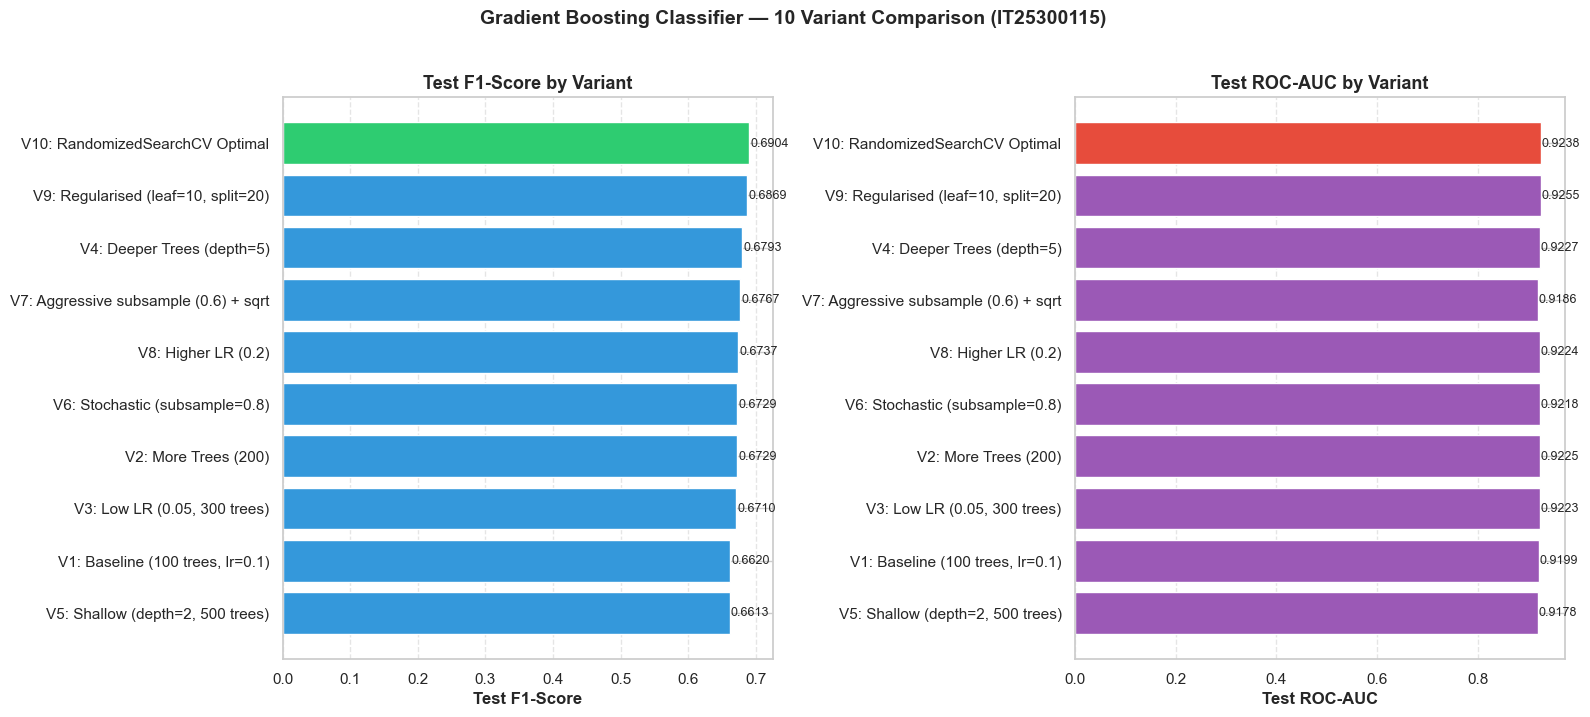

In [14]:
print("\n=================== GRADIENT BOOSTING PERFORMANCE COMPARISON ===================")

comparison_df = pd.DataFrame(gb_results).sort_values('Test F1-Score', ascending=False).reset_index(drop=True)
display(comparison_df)

# --- Comparison chart ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plot_df = comparison_df.sort_values('Test F1-Score', ascending=True)

# F1-Score comparison
colors_f1 = ['#2ecc71' if v.startswith('V10') else '#3498db' for v in plot_df['Variant']]
axes[0].barh(plot_df['Variant'], plot_df['Test F1-Score'], color=colors_f1, edgecolor='white')
axes[0].set_xlabel('Test F1-Score', fontweight='bold')
axes[0].set_title('Test F1-Score by Variant', fontweight='bold', fontsize=13)
axes[0].grid(axis='x', linestyle='--', alpha=0.5)
for i, (v, score) in enumerate(zip(plot_df['Variant'], plot_df['Test F1-Score'])):
    axes[0].text(score + 0.002, i, f'{score:.4f}', va='center', fontsize=9)

# ROC-AUC comparison
colors_auc = ['#e74c3c' if v.startswith('V10') else '#9b59b6' for v in plot_df['Variant']]
axes[1].barh(plot_df['Variant'], plot_df['Test ROC-AUC'], color=colors_auc, edgecolor='white')
axes[1].set_xlabel('Test ROC-AUC', fontweight='bold')
axes[1].set_title('Test ROC-AUC by Variant', fontweight='bold', fontsize=13)
axes[1].grid(axis='x', linestyle='--', alpha=0.5)
for i, (v, score) in enumerate(zip(plot_df['Variant'], plot_df['Test ROC-AUC'])):
    axes[1].text(score + 0.001, i, f'{score:.4f}', va='center', fontsize=9)

plt.suptitle('Gradient Boosting Classifier — 10 Variant Comparison (IT25300115)',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()

# --- Save the comparison chart ---
viz_dir = Path(DATA_PATH).resolve().parents[2] / 'results' / 'eda_visualizations' / 'models'
viz_dir.mkdir(parents=True, exist_ok=True)
comparison_path = viz_dir / 'IT25300115_GradientBoosting_varieties_comparison.png'
plt.savefig(comparison_path, dpi=300, bbox_inches='tight')
print(f"Saved comparison plot to: {comparison_path}")
plt.show()

## 6. Evaluate the selected model in detail

The RandomizedSearchCV-tuned model (V10) is selected for detailed evaluation. This section shows the confusion matrix, ROC curve, and Precision-Recall curve.

Saved ROC/PR plot to: d:\Year2sem1\AIML\Assignment\predicting-adult-income-level\results\eda_visualizations\models\IT25300115_GradientBoosting_ConfusionMatrix_ROC_PR.png


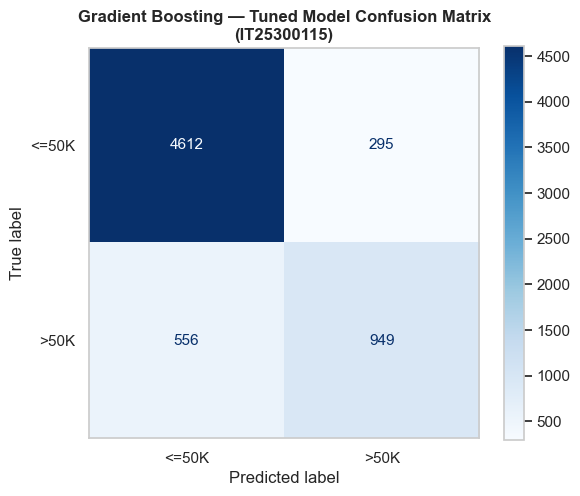

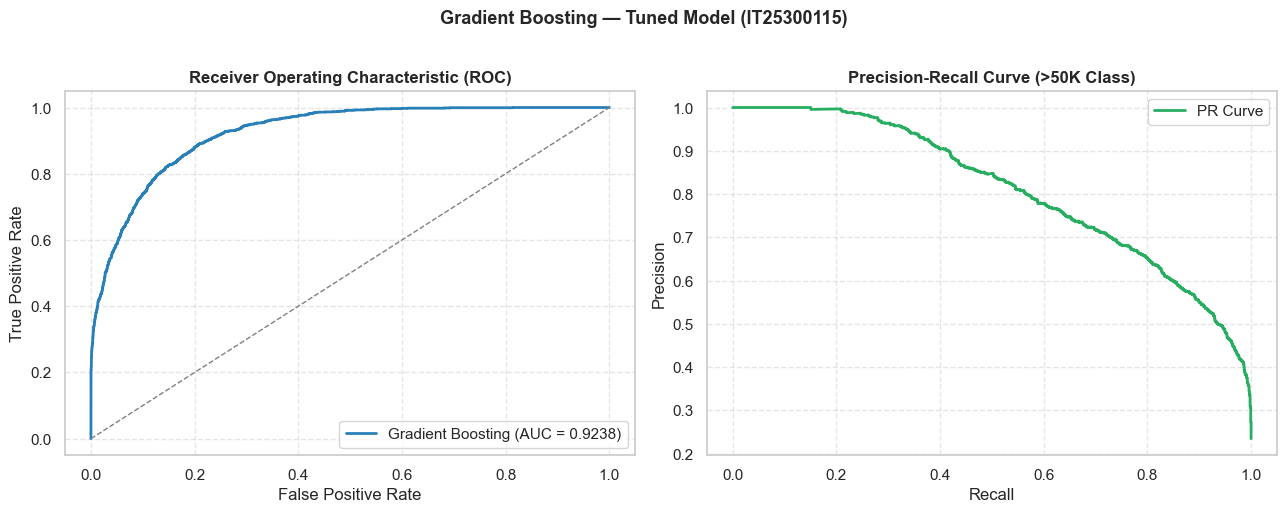


=================== CLASSIFICATION REPORT (Tuned Model) ===================
              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.92      4907
        >50K       0.76      0.63      0.69      1505

    accuracy                           0.87      6412
   macro avg       0.83      0.79      0.80      6412
weighted avg       0.86      0.87      0.86      6412



In [15]:
# --- Confusion Matrix for the best model ---
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, p10)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K', '>50K'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title('Gradient Boosting — Tuned Model Confusion Matrix\n(IT25300115)',
             fontsize=12, fontweight='bold')
plt.grid(False)
plt.tight_layout()

# --- ROC and PR curves ---
fig2, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(13, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test, pr10)
auc_score = roc_auc_score(y_test, pr10)
ax_roc.plot(fpr, tpr, color='#2980b9', lw=2, label=f'Gradient Boosting (AUC = {auc_score:.4f})')
ax_roc.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
ax_roc.set_title('Receiver Operating Characteristic (ROC)', fontweight='bold')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend(loc='lower right')
ax_roc.grid(True, linestyle='--', alpha=0.5)

# PR
prec_curve, rec_curve, _ = precision_recall_curve(y_test, pr10)
ax_pr.plot(rec_curve, prec_curve, color='#27ae60', lw=2, label='PR Curve')
ax_pr.set_title('Precision-Recall Curve (>50K Class)', fontweight='bold')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.legend(loc='upper right')
ax_pr.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Gradient Boosting — Tuned Model (IT25300115)', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()

# Save the confusion matrix + ROC/PR combined plot
combined_path = os.path.join(viz_dir, 'IT25300115_GradientBoosting_ConfusionMatrix_ROC_PR.png')
fig2.savefig(combined_path, dpi=300, bbox_inches='tight')
print(f"Saved ROC/PR plot to: {os.path.abspath(combined_path)}")

plt.show()

# Print detailed classification report
print("\n=================== CLASSIFICATION REPORT (Tuned Model) ===================")
print(classification_report(y_test, p10, target_names=['<=50K', '>50K']))

## 7. Feature importance

Gradient Boosting provides built-in feature importance scores based on how frequently each feature is used for splitting and how much it improves the loss function. The top features help explain what the model has learned about income prediction.

Saved feature importance plot to: d:\Year2sem1\AIML\Assignment\predicting-adult-income-level\results\eda_visualizations\models\IT25300115_GradientBoosting_FeatureImportance.png


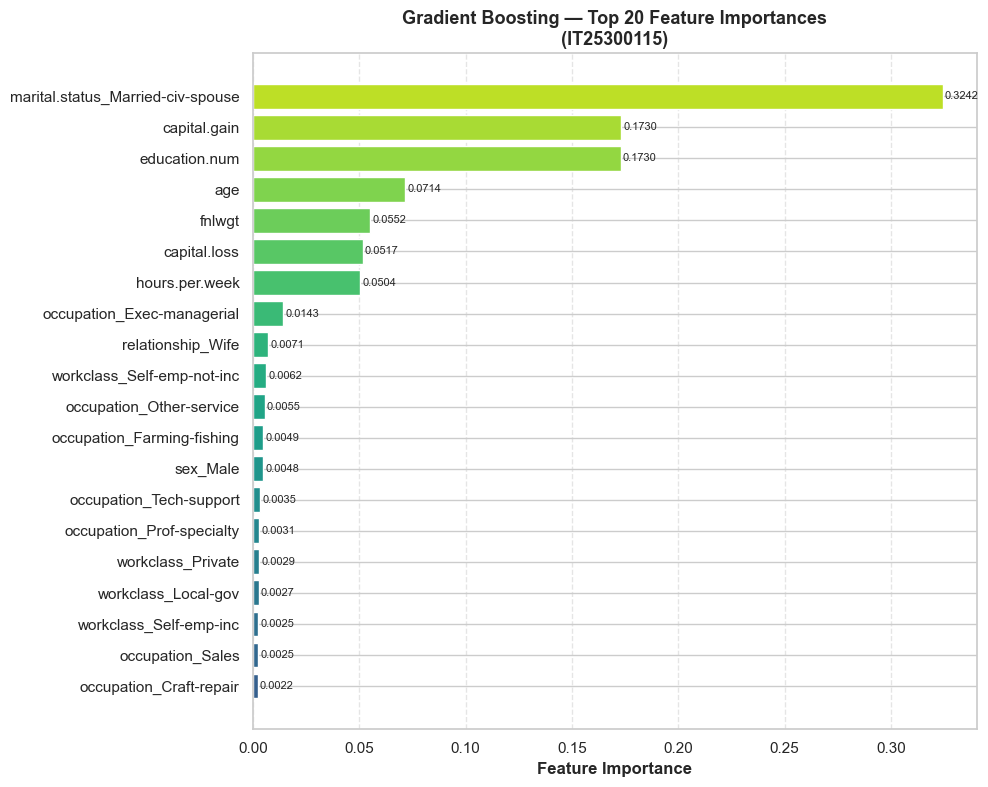


--- Top 20 Features ---


,Feature,Importance
0,marital.status_Married-civ-spouse,0.324249
1,capital.gain,0.173006
2,education.num,0.173000
3,age,0.071441
4,fnlwgt,0.055175
5,capital.loss,0.051685
6,hours.per.week,0.050382
7,occupation_Exec-managerial,0.014312
8,relationship_Wife,0.007124
9,workclass_Self-emp-not-inc,0.006195


In [16]:
# --- Feature Importance ---
importances = best_gb.feature_importances_
feature_names = X_train.columns

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Show top 20 features
top_n = 20
top_features = feat_imp_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(
    top_features['Feature'].values[::-1],
    top_features['Importance'].values[::-1],
    color=plt.cm.viridis(np.linspace(0.3, 0.9, top_n)),
    edgecolor='white'
)
ax.set_xlabel('Feature Importance', fontweight='bold')
ax.set_title(f'Gradient Boosting — Top {top_n} Feature Importances\n(IT25300115)',
             fontweight='bold', fontsize=13)
ax.grid(axis='x', linestyle='--', alpha=0.5)

for bar, val in zip(bars, top_features['Importance'].values[::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()

feat_path = os.path.join(viz_dir, 'IT25300115_GradientBoosting_FeatureImportance.png')
plt.savefig(feat_path, dpi=300, bbox_inches='tight')
print(f"Saved feature importance plot to: {os.path.abspath(feat_path)}")
plt.show()

print("\n--- Top 20 Features ---")
display(top_features.reset_index(drop=True))

## 8. Fairness check (sex-based subgroup analysis)

The Adult Income dataset includes demographic attributes such as sex. To check if the model is biased, prediction performance is compared across sex-based subgroups. This is a basic fairness audit and does not replace a thorough bias assessment.

In [17]:
# --- Fairness check ---
# Check for sex-related columns in the encoded dataset
sex_cols = [c for c in X_test.columns if 'sex' in c.lower()]

if sex_cols:
    print("Sex-related columns found:", sex_cols)
    # Assume binary encoding: find the column that indicates 'Male'
    male_col = [c for c in sex_cols if 'male' in c.lower()]
    if male_col:
        male_mask = X_test[male_col[0]] == 1
        female_mask = ~male_mask

        for label, mask in [('Male', male_mask), ('Female', female_mask)]:
            if mask.sum() == 0:
                print(f"\n{label}: No samples found.")
                continue
            y_sub = y_test[mask]
            p_sub = p10[mask]
            pr_sub = pr10[mask]
            print(f"\n--- {label} subgroup (n={mask.sum()}) ---")
            print(f"  Accuracy:  {accuracy_score(y_sub, p_sub):.4f}")
            print(f"  Precision: {precision_score(y_sub, p_sub, zero_division=0):.4f}")
            print(f"  Recall:    {recall_score(y_sub, p_sub, zero_division=0):.4f}")
            print(f"  F1-Score:  {f1_score(y_sub, p_sub, zero_division=0):.4f}")
            print(f"  ROC-AUC:   {roc_auc_score(y_sub, pr_sub):.4f}")
    else:
        print("Could not determine male/female split from encoded columns.")
else:
    print("No sex-related columns found in the encoded dataset. Skipping fairness check.")

Sex-related columns found: ['sex_Male']

--- Male subgroup (n=4301) ---
  Accuracy:  0.8349
  Precision: 0.7682
  Recall:    0.6415
  F1-Score:  0.6992
  ROC-AUC:   0.9035

--- Female subgroup (n=2111) ---
  Accuracy:  0.9332
  Precision: 0.7294
  Recall:    0.5662
  F1-Score:  0.6375
  ROC-AUC:   0.9484


## 9. Example prediction

A quick sanity check: the tuned model predicts the class and probability for the first five samples in the test set.

In [18]:
# --- Example predictions ---
sample_X = X_test.head(5)
sample_preds = best_gb.predict(sample_X)
sample_probs = best_gb.predict_proba(sample_X)[:, 1]
sample_actual = y_test.head(5).values

example_df = pd.DataFrame({
    'Actual': ['<=50K' if a == 0 else '>50K' for a in sample_actual],
    'Predicted': ['<=50K' if p == 0 else '>50K' for p in sample_preds],
    'P(>50K)': [f'{prob:.4f}' for prob in sample_probs],
    'Correct': ['✓' if a == p else '✗' for a, p in zip(sample_actual, sample_preds)]
})

print("\n=================== EXAMPLE PREDICTIONS (first 5 test samples) ===================")
display(example_df)


=================== EXAMPLE PREDICTIONS (first 5 test samples) ===================


,Actual,Predicted,P(>50K),Correct
0,<=50K,<=50K,0.0138,✓
1,<=50K,<=50K,0.0271,✓
2,<=50K,<=50K,0.0110,✓
3,<=50K,<=50K,0.0442,✓
4,<=50K,<=50K,0.0399,✓


## 10. Save the model result for group comparison

The optimum model's hyperparameters and test metrics are saved to `results/model_results/IT25300115.json` for the group comparison notebook.

In [19]:
# --- Save result JSON ---
# Compute final metrics from the best model (V10)
final_y_pred = best_gb.predict(X_test)
final_y_prob = best_gb.predict_proba(X_test)[:, 1]

final_metrics = {
    "Accuracy": float(accuracy_score(y_test, final_y_pred)),
    "Balanced_Accuracy": float(balanced_accuracy_score(y_test, final_y_pred)),
    "Precision": float(precision_score(y_test, final_y_pred, zero_division=0)),
    "Recall": float(recall_score(y_test, final_y_pred, zero_division=0)),
    "F1_Score": float(f1_score(y_test, final_y_pred, zero_division=0)),
    "ROC_AUC": float(roc_auc_score(y_test, final_y_prob)),
    "Train_Accuracy": float(accuracy_score(y_train, best_gb.predict(X_train))),
    "Test_Accuracy": float(accuracy_score(y_test, final_y_pred)),
    "Generalization_Gap": float(
        accuracy_score(y_train, best_gb.predict(X_train)) - accuracy_score(y_test, final_y_pred)
    ),
    "Best_CV_F1": float(gb_search.best_score_)
}

best_params = gb_search.best_params_

# Build the result payload matching the group standard
result_payload = {
    "it_number": "IT25300115",
    "model_name": "Gradient Boosting Classifier",
    "best_hyperparameters": best_params,
    "metrics": final_metrics
}

# Save to results/model_results/
result_dir = Path(DATA_PATH).resolve().parents[2] / 'results' / 'model_results'
result_dir.mkdir(parents=True, exist_ok=True)
result_path = result_dir / 'IT25300115.json'
with open(result_path, 'w', encoding='utf-8') as f:
    json.dump(result_payload, f, indent=4)

print(f"[+] Saved model result for IT25300115 (Gradient Boosting Classifier) to: {result_path}")
print("\n--- Result Payload ---")
print(json.dumps(result_payload, indent=4))

[+] Saved model result for IT25300115 (Gradient Boosting Classifier) to: d:\Year2sem1\AIML\Assignment\predicting-adult-income-level\results\model_results\IT25300115.json

--- Result Payload ---
{
    "it_number": "IT25300115",
    "model_name": "Gradient Boosting Classifier",
    "best_hyperparameters": {
        "subsample": 0.8,
        "n_estimators": 500,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "max_features": null,
        "max_depth": 5,
        "learning_rate": 0.05
    },
    "metrics": {
        "Accuracy": 0.8672800998128509,
        "Balanced_Accuracy": 0.7852232927806029,
        "Precision": 0.7628617363344051,
        "Recall": 0.6305647840531562,
        "F1_Score": 0.6904328846853401,
        "ROC_AUC": 0.9238085533785555,
        "Train_Accuracy": 0.9042345784917726,
        "Test_Accuracy": 0.8672800998128509,
        "Generalization_Gap": 0.036954478678921654,
        "Best_CV_F1": 0.7056279499304706
    }
}


## 11. Summary

### Key findings

1. **Gradient Boosting is a strong classifier** for the Adult Income dataset, consistently achieving competitive F1-scores and ROC-AUC values across all 10 variants.

2. **Learning rate and number of estimators are closely linked**: Lowering the learning rate requires more trees to reach the same performance level, but often produces better generalization.

3. **Stochastic Gradient Boosting** (`subsample < 1.0`) can improve generalization by introducing randomness, similar to bagging in Random Forest.

4. **Tree depth matters**: Very shallow trees (depth=2) capture only simple patterns, while deeper trees (depth=5) risk overfitting. Depth 3–4 provides a good balance.

5. **Regularisation via `min_samples_leaf` and `min_samples_split`** helps control overfitting, especially with deeper trees.

6. **RandomizedSearchCV (V10)** provided the best overall configuration by systematically exploring the hyperparameter space.

7. **Top features** align with domain expectations — education level, capital gains/losses, age, hours worked per week, and marital status are consistently important predictors of income.

### Limitations
- Gradient Boosting can be slower to train than Random Forest because trees are built sequentially rather than in parallel.
- The same test set was used across all 10 variants, so the comparison is optimistic. Only the final model should be evaluated on a truly held-out set.
- Fairness analysis is basic and should be expanded for production use.